HTTP Status Code: 200
Content-Type: image/jpeg


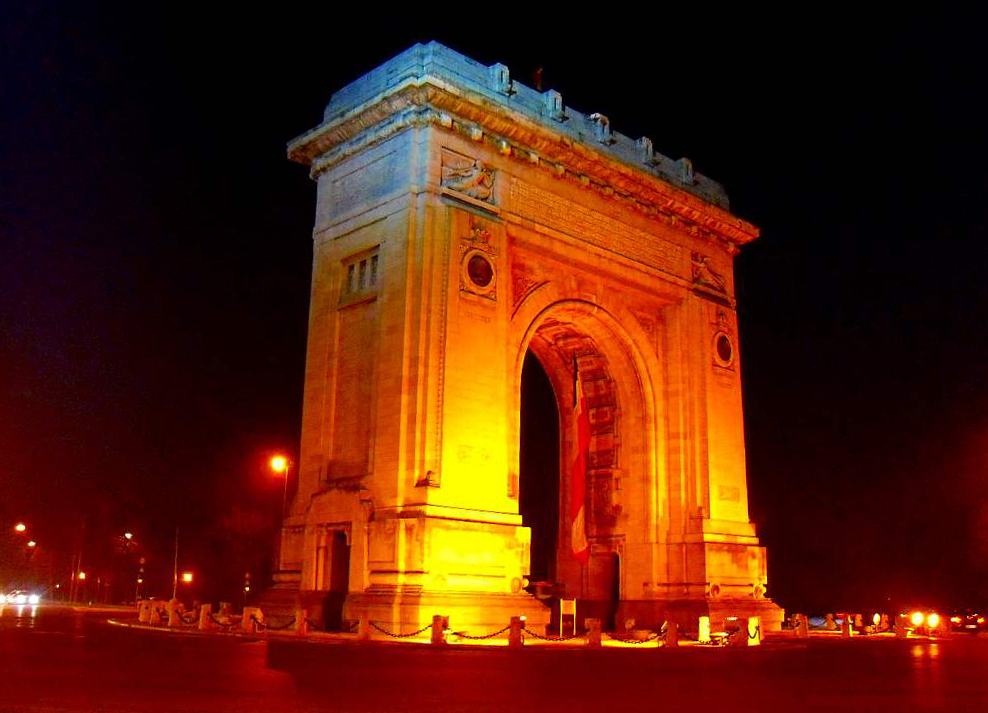

In [4]:
!pip install qwen_vl_utils

import os          # File‑system helpers (paths, env vars, etc.)
import random      # Lightweight randomness (e.g. sample prompts)
import textwrap    # Nicely format long strings for display
import io          # In‑memory byte streams (e.g. image buffers)
import requests    # Simple HTTP requests for downloading assets
import numpy as np  # Core array maths (fast, vectorised operations)
import torch  # Tensor library + GPU acceleration
from transformers import (Qwen2_5_VLForConditionalGeneration, AutoProcessor)  # Multimodal LLM (image+text)  # Paired tokenizer/feature‑extractor
from PIL import Image                    # Pillow: load/save/manipulate images
import matplotlib.pyplot as plt          # Quick plots in notebooks
import matplotlib.patches as patches     # Bounding‑box overlays, etc.
from qwen_vl_utils import process_vision_info  # Post‑process Qwen outputs
import IPython.display as ipd             # Inline display (images, audio, HTML)
from IPython.display import display

# Updated URL to directly point to the image file
url="https://upload.wikimedia.org/wikipedia/ro/f/fd/Arcul_de_Triumf_-_Bucuresti.jpg"

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

try:
    # Use requests to get the image content with headers
    response = requests.get(url, headers=headers, stream=True)
    response.raise_for_status() # Raise an exception for HTTP errors (4xx or 5xx)

    # Debugging information
    print(f"HTTP Status Code: {response.status_code}")
    print(f"Content-Type: {response.headers.get('Content-Type')}")

    # Save the image content to a file
    with open('img.jpg', 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    img = Image.open('img.jpg')
    display(img)
except requests.exceptions.RequestException as e:
    print(f"Error downloading image: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")



In [5]:

device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype="auto",     # automatically uses FP16 on GPU, FP32 on CPU
    device_map="auto"       # dispatches layers to the available device(s)
)
processor = AutoProcessor.from_pretrained(model_id)

print(f"Model loaded on: {model.device}")

msgs = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text",  "text": "Describe this image."}
        ],
    }
]

text_prompt = processor.apply_chat_template(
    msgs,
    tokenize=False,
    add_generation_prompt=True
)

# For sanity-checking: print the raw prompt string that will be fed to the model
print(text_prompt)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded on: cpu
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>Describe this image.<|im_end|>
<|im_start|>assistant



In [6]:
image_inputs, video_inputs = process_vision_info(msgs)


In [7]:
inputs = processor(
    text=[text_prompt],      # 1-element batch containing the chat prompt string
    images=image_inputs,     # list of raw PIL images (pre-processed inside processor)
    videos=video_inputs,     # list of raw video clips (if any)
    padding=True,            # pad sequences so text/vision tokens line up in a batch
    return_tensors="pt",     # return a dict of PyTorch tensors (input_ids, pixel_values, …)
).to(model.device)           # move every tensor—text & vision—to the model’s GPU/CPU


In [8]:
with torch.no_grad():                     # disable autograd to save memory
    generated_ids = model.generate(       # autoregressive decoding
        **inputs,                         # unpack dict into generate(...)
        max_new_tokens=50                # Reduce to 50 tokens for faster generation
    )


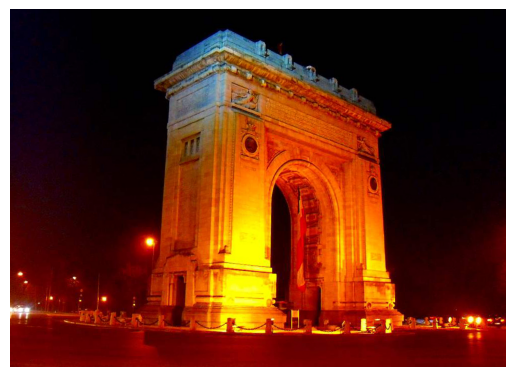

The image depicts a large, monumental arch structure illuminated at night. This
arch is likely a historical or cultural landmark, given its grandeur and the
prominence of its design. The structure features an archway in the center, which
is flanked by two


In [9]:
# Extract the newly generated tokens (skip the prompt length)
caption = processor.batch_decode(
    generated_ids[:, inputs.input_ids.shape[-1]:],
    skip_special_tokens=True
)[0]

# Display the image
plt.imshow(img)
plt.axis("off")
plt.show()

# Print caption
width = 80
wrapped_caption = textwrap.fill(caption, width)
print(wrapped_caption)
